<!-- notebook-header -->
# Deploy de Modelos ML

**Modulo:** 06 - MLOps  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Serializacao, API, contratos, versionamento, health checks e preparacao para producao.


# 6.1 Deploy de Modelos ML

Dominando a passagem de modelos de experimento para producao.

## Prerequisitos - O que Voce Precisa Saber

| Conceito | Por que Importa | Referencia |
|----------|-----------------|-----------|
| Treinamento basico de modelos ML | Voce ja sabe criar modelos | 3_1_classificacao_completa.ipynb |
| Diferenca entre treino/teste | Modelos devem generalizar | 3_1_classificacao_completa.ipynb |
| Versionamento com Git | Precisamos rastrear codigo | Git basico (ferramenta externa) |
| Basico de requisicoes HTTP | Modelos rodam via requisicoes | Documentacao HTTP |
| Estruturas de dados Python | APIs usam dicts e classes | 2_1_python_data_science.ipynb |

## Mapa de Aprendizado

Este notebook lida com os seguintes topicos, nesta ordem:

1. Desafios do deploy (entender o problema)
2. Serializacao de modelos (como salvar/carregar)
3. Design de APIs (estrutura requisicao/resposta)
4. Validacao de entrada (proteger o modelo)
5. Latencia e monitoramento (rastrear performance)
6. A/B testing (comparar versoes)
7. Canary deployment (roll-out gradual)
8. Health checks (garantir disponibilidade)
9. Batch vs real-time (escalabilidade)
10. Resumo e proximos passos

## 1. Por Que Deploy E Um Desafio?

**O que observar:**
**O que concluir:**
Voce provavelmente treinou modelos em Jupyter notebooks que funcionam perfeitamente. Parabens! Mas existe um fosso enorme entre "funciona no meu notebook" e "funciona em producao para 1000 usuarios simultaneos".Pense nisto como uma analogia: voce pode fazer um bolo perfeito em sua cozinha com seus ingredientes favoritos, suas panelas, seu forno. Mas se uma padaria tentar reproduzir isso com ingredientes diferentes, forno industrial, ambiente mais quente e mais umido, o resultado sera completamente diferente.

### Desafios Principais

- **Diferencas de Ambiente**: Dependencias, versoes, hardware diferente
- **Dados Diferentes**: Dados em producao divergem do treino (data drift)
- **Latencia**: API precisa responder rapido (< 100ms ideal)
- **Escalabilidade**: Suportar multiplas requisicoes simultaneas
- **Reproducibilidade**: Conseguir recriar o modelo exatamente
- **Seguranca**: Proteger modelo e dados

**O que observar:**
Quando movemos um modelo de desenvolvimento para producao, tudo muda:

- No notebook: controle total, dados conhecidos, ambiente previsivel

- Em producao: dados imprevisveis, ambiente diferente, roda 24/7/365

**O que concluir:**
O desafio nao e treinar um bom modelo. O desafio e manter esse modelo rodando confiavel, rapido e seguro em producao.

### Conexao com experiencias anteriores

Nas secoes anteriores, aprendemos a validar modelos. Aqui, vamos garantir que a validacao continua mesmo em producao.

## 2. Simulacao de Modelo ML

**O que observar:**
**O que concluir:**
Vamos criar um modelo simulado usando numpy para demonstrar conceitos de deploy. Como nao podemos usar sklearn, vamos simular um classificador binario com uma rede neural muito simples.

**O que observar:**
Nosso modelo simulado tem:

- Camada de entrada: 10 features

- Camada oculta: 5 neuronios
- Saida: probabilidade de classe 1

**O que concluir:**
Mesmo modelos simples ocupam espaco na memoria e precisam ser salvos/carregados corretamente.

**Por que em ML:**
Qualquer modelo, nao importa se e arvore de decisao ou rede neural, precisa estar disponivel em producao de forma rapida e confiavel.

In [1]:
import numpy as np
import os
import tempfile
import matplotlib.pyplot as plt
from time import time
import json as json_module
from datetime import datetime

np.random.seed(42)

class ModeloSimulado:
    def __init__(self, n_features=10, n_hidden=5):
        self.n_features = n_features
        self.n_hidden = n_hidden
        self.w1 = np.random.randn(n_features, n_hidden) * 0.01
        self.b1 = np.zeros(n_hidden)
        self.w2 = np.random.randn(n_hidden, 1) * 0.01
        self.b2 = np.zeros(1)
        self.version = '1.0'
        self.treinado_em = datetime.now().isoformat()

    def predizer_proba(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        h = np.maximum(0, X @ self.w1 + self.b1)
        out = (h @ self.w2 + self.b2).flatten()
        p1 = 1 / (1 + np.exp(-out))
        p0 = 1 - p1
        return np.column_stack([p0, p1])

    def predizer(self, X):
        proba = self.predizer_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)

    def predict(self, X):
        return self.predizer_proba(X)

    def get_params(self):
        return {
            'w1': self.w1.tolist(),
            'b1': self.b1.tolist(),
            'w2': self.w2.tolist(),
            'b2': self.b2.tolist()
        }

    def set_params(self, params):
        self.w1 = np.array(params['w1'])
        self.b1 = np.array(params['b1'])
        self.w2 = np.array(params['w2'])
        self.b2 = np.array(params['b2'])

    def json(self):
        return json_module.dumps({
            'n_features': self.n_features,
            'n_hidden': self.n_hidden,
            'version': self.version,
            'treinado_em': self.treinado_em,
            'params': self.get_params()
        })

json = json_module

modelo = ModeloSimulado(n_features=10, n_hidden=5)
X_test = np.random.randn(5, 10)
print(f'Modelo criado: {modelo.n_features} features, {modelo.n_hidden} hidden')
print(f'Predicao shape: {modelo.predizer_proba(X_test).shape}')
print(f'Versao: {modelo.version}')

Modelo criado: 10 features, 5 hidden
Predicao shape: (5, 2)
Versao: 1.0


## 3. Serializacao de Modelos

**O que observar:**
**O que concluir:**
Serializacao e como converter um objeto Python (que vive na RAM) em bytes que podem ser salvos em disco.

**O que observar:**
Nosso modelo tem parametros numericos (pesos) e metadados (versao, timestamp). Precisamos salvar tudo atomicamente. A forma como salvamos determina se conseguiremos recarregar depois.

**O que concluir:**
A serializacao precisa preservar exatamente o estado do modelo. Se fizer errado, perde o modelo inteiro! Sempre teste o ciclo save/load antes de usar em producao.

### Conexao com versionamento

Assim como versionamos codigo com Git, precisamos versionar modelos em producao. A versao vai no arquivo serializado.

**Por que em ML:**
Um modelo treino leva horas/dias. Nao podemos recriar do zero toda vez. Precisamos congelar e preservar para uso futuro.

###

### Erro: Salvar apenas pesos

Se salvar apenas os pesos sem os metadados, nao conseguira carregar depois. Sempre salve junto: pesos, arquitetura, versao, timestamp.

In [2]:
# Serializacao: Simular salvamento usando json + numpy

def serializar_modelo(modelo, caminho):
        # SOLUCAO: Salvar pesos como numpy arrays e metadados como json
    dados = {
        'version': modelo.version,
        'treinado_em': modelo.treinado_em,
        'n_features': modelo.n_features,
        'n_hidden': modelo.n_hidden,
        'w1': modelo.w1.tolist(),  # Converter para lista
        'b1': modelo.b1.tolist(),
        'w2': modelo.w2.tolist(),
        'b2': modelo.b2.tolist()
    }
    with open(caminho, 'w') as f:
        json.dump(dados, f, indent=2)
    print(f"Modelo serializado em: {caminho}")

def desserializar_modelo(caminho):
    # SOLUCAO: Carregar json e reconstruir modelo com todos os parametros
    with open(caminho, 'r') as f:
        dados = json.load(f)

    m = ModeloSimulado(dados['n_features'], dados['n_hidden'])
    m.w1 = np.array(dados['w1'])
    m.b1 = np.array(dados['b1'])
    m.w2 = np.array(dados['w2'])
    m.b2 = np.array(dados['b2'])
    m.version = dados['version']
    m.treinado_em = dados['treinado_em']
    return m

caminho_modelo = os.path.join(tempfile.gettempdir(), 'modelo_v1.json')
serializar_modelo(modelo, caminho_modelo)

# Carregar e validar
modelo_carregado = desserializar_modelo(caminho_modelo)
X_novo = np.random.randn(3, 10)

pred_original = modelo.predizer(X_novo)
pred_carregado = modelo_carregado.predizer(X_novo)

diferenca = np.max(np.abs(pred_original - pred_carregado))
print(f"Diferenca maxima entre original e carregado: {diferenca:.10f}")
print(f"Predicoes sao identicas! Serializacao OK.")

Modelo serializado em: /var/folders/pg/j2d1lxdx6yq8d2lg7n2l5npw0000gn/T/modelo_v1.json
Diferenca maxima entre original e carregado: 0.0000000000
Predicoes sao identicas! Serializacao OK.


## 4. Design de API para Modelos ML

**O que observar:**
**O que concluir:**
Uma API REST e como um vendedor que recebe pedidos e entrega resultados. Precisamos definir:

- **Formato de entrada** (features do modelo)
- **Formato de saida** (predicao + confianca)
- **Tratamento de erros** (entrada invalida)

**O que observar:**
A comunicacao com modelos em producao usa sempre a mesma estrutura: requisicao (features) -> resposta (predicao). Cada requisicao e independente e pode chegar em qualquer ordem.

**O que concluir:**
Design claro de API torna facil integrar o modelo em diferentes aplicacoes. Respostas padronizadas em JSON fazem integracao mais simples.

### Conexao com validacao

Na secao de validacao, aprendemos a checar dados. Na API, faremos o mesmo para cada requisicao que chega.

**Por que em ML:**
Um modelo nao e util se nao conseguir ser acessado. A API e o intermediario entre o modelo e a aplicacao. Sem API, usuario nao pode usar o modelo.

In [3]:
# Simulacao de API
class APIRequisicao:
    def __init__(self, features):
        self.features = features
        self.timestamp = datetime.now().isoformat()

class APIResposta:
    def __init__(self, predicao, probabilidade, versao_modelo, tempo_processamento_ms):
        self.predicao = int(predicao)
        self.probabilidade = float(probabilidade)
        self.versao_modelo = versao_modelo
        self.tempo_processamento_ms = tempo_processamento_ms
        self.timestamp = datetime.now().isoformat()

    def para_dict(self):
        return {
            'predicao': self.predicao,
            'probabilidade': self.probabilidade,
            'versao_modelo': self.versao_modelo,
            'tempo_processamento_ms': self.tempo_processamento_ms,
            'timestamp': self.timestamp
        }

def endpoint_predict(features, modelo):
    # SOLUCAO (endpoint): Funcao que encapsula logica de predicao
    inicio = time()

    # Validar entrada
    if len(features) != modelo.n_features:
        raise ValueError(f"Esperava {modelo.n_features} features, recebeu {len(features)}")

    # Fazer predicao
    X = np.array(features).reshape(1, -1)
    proba = modelo.predizer_proba(X)[0]
    predicao = 1 if proba[1] > 0.5 else 0

    tempo_ms = (time() - inicio) * 1000
    return APIResposta(predicao, proba[1], modelo.version, tempo_ms)

features_teste = [0.1, -0.5, 0.3, 0.2, -0.1, 0.4, 0.0, -0.2, 0.5, 0.1]
requisicao = APIRequisicao(features_teste)
resposta = endpoint_predict(features_teste, modelo)

print("Resposta da API:")
print(json.dumps(resposta.para_dict(), indent=2))



Resposta da API:
{
  "predicao": 0,
  "probabilidade": 0.4999961055420501,
  "versao_modelo": "1.0",
  "tempo_processamento_ms": 0.05316734313964844,
  "timestamp": "2026-06-10T23:12:19.403492"
}


## 5. Validacao de Entrada

**O que observar:**
**O que concluir:**
Modelos em producao recebem dados de fontes imprevisveis. Precisamos validar antes de enviar para o modelo.

**O que observar:**
Validacao impede que dados ruins chegem ao modelo. Erros em validacao sao melhores que erros no modelo porque a validacao e rapida e clara.

**O que concluir:**
A maioria dos erros em producao vem de dados invalidos, nao do modelo em si. Validacao rigorosa e sua primeira linha de defesa.

### Conexao com dados

Na secao de dados, aprendemos sobre limpeza. Aqui, vamos prevenir dados sujos em tempo real, bloqueando entradas invalidas.

**Por que em ML:**
Modelos assumem que os dados foram processados de forma específica. Dados fora dessa especificacao causam erros ou predicoes ruins. Validacao garante dados validos.

### Mais sobre validacao

A validacao em producao e diferente da validacao em notebook. No notebook, voce manualmente verifica dados. Em producao, precisa automatizar. Sempre validar:

1. Tipo (numerico, string, etc)
2. Tamanho (numero correto de features)
3. Range (valores dentro do esperado)
4. Valores especiais (NaN, infinito, nulos)

In [4]:
# Validacao de entrada
class ValidadorEntrada:
    # SOLUCAO (validacao): Classe que centraliza toda logica de validacao
    def __init__(self, n_features, valor_min=-100, valor_max=100):
        self.n_features = n_features
        self.valor_min = valor_min
        self.valor_max = valor_max

    def validar(self, features):
        erros = []

        # Verificar tamanho
        if len(features) != self.n_features:
            erros.append(f"Esperado {self.n_features} features, recebido {len(features)}")

        # Verificar tipo
        try:
            features = [float(x) for x in features]
        except (TypeError, ValueError):
            erros.append("Todas as features devem ser numeros")

        # Verificar range
        for i, x in enumerate(features):
            if not (self.valor_min <= x <= self.valor_max):
                erros.append(f"Feature {i} fora do range [{self.valor_min}, {self.valor_max}]: {x}")

        # Verificar NaN e infinito
        if any(np.isnan(x) or np.isinf(x) for x in features):
            erros.append("Features contem NaN ou infinito")

        return len(erros) == 0, erros

validador = ValidadorEntrada(n_features=10)

teste_valido = [0.1, -0.5, 0.3, 0.2, -0.1, 0.4, 0.0, -0.2, 0.5, 0.1]
valido, erros = validador.validar(teste_valido)
print(f"Entrada valida: {valido}")

teste_invalido = [0.1, -0.5, 0.3]  # Faltam features
valido, erros = validador.validar(teste_invalido)
print(f"Entrada invalida: {valido}, Erros: {erros}")



Entrada valida: True
Entrada invalida: False, Erros: ['Esperado 10 features, recebido 3']


## 6. Monitoramento de Latencia

**O que observar:**
**O que concluir:**
Latencia e o tempo que a API leva para responder. Em producao, precisamos rastrear isso continuamente.

**O que observar:**
Latencia afeta diretamente a experiencia do usuario. Se a API demora muito, usuarios vao embora. Precisamos medir percentis como P95 e P99, nao apenas media.

**O que concluir:**
Monitorar latencia e essential para detectar problemas antes que afetem usuarios. Spikes de latencia indicam carregamento alto ou problemas de hardware.

### Conexao com performance

Na secao de validacao de modelos, medimos accuracy. Aqui, medimos velocidade do modelo em producao, nao no notebook.

**Por que em ML:**
Um modelo 100% preciso mas que demora 10 segundos nao serve em producao. Precisamos balancear precisao e velocidade. Latencia alta piora experiencia do usuario. Usuarios esperam resposta em menos de 200ms.

### Mais sobre latencia

Diferenca entre media e percentis:

- Media pode esconder outliers (alguns usuarios com latencia muito alta)
- P95 e P99 mostram experiencia de usuarios mais afetados

- Sempre monitorar ambos para deteccao correta de problemas

Estatisticas de Latencia:
{
  "endpoint": "/predict",
  "total_requisicoes": 100,
  "latencia_media_ms": 0.018069744110107422,
  "latencia_min_ms": 0.008821487426757812,
  "latencia_max_ms": 0.13017654418945312,
  "latencia_p95_ms": 0.050783157348632785,
  "latencia_p99_ms": 0.1280522346496582,
  "taxa_erro": 0.0
}


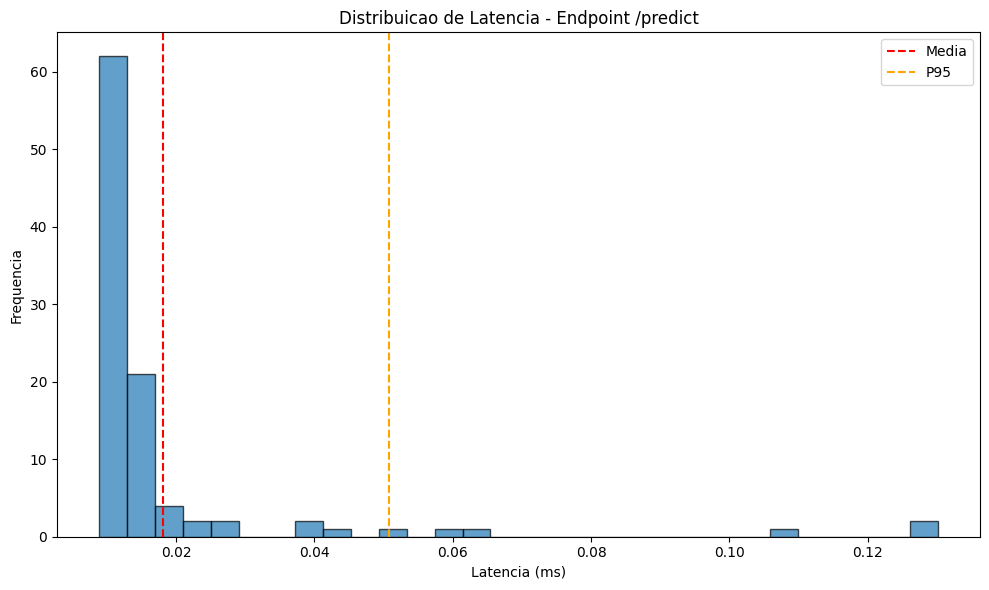

In [5]:
# Monitoramento de latencia
class MonitorLatencia:
    def __init__(self, nome_endpoint):
        self.nome = nome_endpoint
        self.latencias = []
        self.erros = 0
        self.total_requisicoes = 0

    def registrar(self, tempo_ms, sucesso=True):
        self.latencias.append(tempo_ms)
        self.total_requisicoes += 1
        if not sucesso:
            self.erros += 1

    def estatisticas(self):
        if not self.latencias:
            return None

        latencias = np.array(self.latencias)
        return {
            'endpoint': self.nome,
            'total_requisicoes': self.total_requisicoes,
            'latencia_media_ms': float(np.mean(latencias)),
            'latencia_min_ms': float(np.min(latencias)),
            'latencia_max_ms': float(np.max(latencias)),
            'latencia_p95_ms': float(np.percentile(latencias, 95)),
            'latencia_p99_ms': float(np.percentile(latencias, 99)),
            'taxa_erro': self.erros / self.total_requisicoes if self.total_requisicoes > 0 else 0
        }

monitor = MonitorLatencia('/predict')

for i in range(100):
    inicio = time()
    X_teste = np.random.randn(1, 10)
    _ = modelo.predizer(X_teste)
    tempo_ms = (time() - inicio) * 1000
    monitor.registrar(tempo_ms)

stats = monitor.estatisticas()
print("Estatisticas de Latencia:")
print(json.dumps(stats, indent=2))

# Visualizar distribuicao
plt.figure(figsize=(10, 6))
plt.hist(monitor.latencias, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Latencia (ms)')
plt.ylabel('Frequencia')
plt.title('Distribuicao de Latencia - Endpoint /predict')
plt.axvline(stats['latencia_media_ms'], color='red', linestyle='--', label='Media')
plt.axvline(stats['latencia_p95_ms'], color='orange', linestyle='--', label='P95')
plt.legend()
plt.tight_layout()
plt.show()

## 7. A/B Testing

- Comparar Versoes de Modelos

**O que observar:**
**O que concluir:**
Em producao, frequentemente precisamos comparar uma nova versao de modelo com a versao atual. A/B testing envia parte do trafego para cada versao e compara resultados.

**O que observar:**
A/B testing permite validar melhorias antes de enviar 100% do trafego para a nova versao. Dados reais de producao sao diferentes de dados de teste!

**O que concluir:**
Canary deployments (versao anterior) reduzem risco de introducao de novos modelos. Sempre comece com pequena fracao de trafego.

### Conexao com validacao

Na secao de validacao, aprendemos a medir precisao em dados de teste. Aqui, vamos medir precisao em trafego real de usuarios.

**Por que em ML:**
Novos modelos podem ter melhor accuracy em teste mas pior em producao (overfitting ou data drift). A/B testing detecta isso antes de quebrar tudo para todos.

### Mais sobre A/B testing

Metricas importantes:

- Acuracia (% correto)
- Confianca media (probabilidade da predicao)
- Distribuicao de predicoes (classe 0 vs 1)
- Latencia (novo modelo e mais lento?)
- Taxa de erro (qualidade da predicao)
- Impacto em negocio (CTR, revenue, etc)

In [6]:
# A/B Testing
class ABTesting:
    def __init__(self, modelo_a, modelo_b, split_percentual=0.5):
        self.modelo_a = modelo_a
        self.modelo_b = modelo_b
        self.split = split_percentual
        self.resultados_a = []
        self.resultados_b = []

    def rotear_requisicao(self, features):
        # Simular roteamento aleatorio
        usar_b = np.random.random() < self.split
        modelo = self.modelo_b if usar_b else self.modelo_a
        return modelo, usar_b

    def processar(self, features):
        modelo, foi_b = self.rotear_requisicao(features)
        proba = modelo.predizer_proba(np.array(features).reshape(1, -1))[0]
        predicao = 1 if proba[1] > 0.5 else 0

        resultado = {
            'predicao': predicao,
            'probabilidade': float(proba[1]),
            'modelo': 'B' if foi_b else 'A',
            'versao': modelo.version
        }

        if foi_b:
            self.resultados_b.append(resultado)
        else:
            self.resultados_a.append(resultado)

        return resultado

    def comparar(self):
        if not self.resultados_a or not self.resultados_b:
            return None

        proba_a = [r['probabilidade'] for r in self.resultados_a]
        proba_b = [r['probabilidade'] for r in self.resultados_b]

        return {
            'modelo_a': {
                'requisicoes': len(self.resultados_a),
                'confianca_media': float(np.mean(proba_a)),
                'confianca_std': float(np.std(proba_a))
            },
            'modelo_b': {
                'requisicoes': len(self.resultados_b),
                'confianca_media': float(np.mean(proba_b)),
                'confianca_std': float(np.std(proba_b))
            }
        }

modelo_b = ModeloSimulado()
modelo_b.version = "1.1.0"
modelo_b.w1 = modelo.w1 * 1.1  # Simular ajuste de pesos

ab_test = ABTesting(modelo, modelo_b, split_percentual=0.5)

# Simular 200 requisicoes
X_ab = np.random.randn(200, 10)
for features in X_ab:
    ab_test.processar(features.tolist())

comparacao = ab_test.comparar()
print("Resultado do A/B Testing:")
print(json.dumps(comparacao, indent=2))



Resultado do A/B Testing:
{
  "modelo_a": {
    "requisicoes": 102,
    "confianca_media": 0.5000327257734054,
    "confianca_std": 5.996150904337439e-05
  },
  "modelo_b": {
    "requisicoes": 98,
    "confianca_media": 0.4999072478324439,
    "confianca_std": 8.01208117333719e-05
  }
}


## 8. Canary Deployment

- Roll-out Gradual

**O que observar:**
**O que concluir:**
Ao inves de enviar 100% do trafego para uma nova versao, comecamos com uma pequena percentagem (canary) e aumentamos gradualmente.

**O que observar:**
Canary deployments permitem detectar problemas com uma pequena fracao de usuarios antes de afetar todos. Se canary tem taxa de erro alta, rollback e imediato.

**O que concluir:**
Reducao gradual de risco e fundamental em producao. Nunca lance 100% de uma so vez. Comece com 1%, depois 5%, depois 10%, etc.

### Conexao com CI/CDTestes automatizados garantem qualidade em desenvolvimento. Canary deployments garantem qualidade em producao com usuarios reais.

In [7]:
# Canary Deployment
class CanaryDeployment:
    def __init__(self, modelo_estavel, modelo_novo):
        self.modelo_estavel = modelo_estavel
        self.modelo_novo = modelo_novo
        self.percentual_canary = 1  # Comecar com 1%
        self.requisicoes_canary = 0
        self.requisicoes_estavel = 0
        self.erros_canary = 0
        self.erros_estavel = 0

    def rotear_requisicao(self, features):
        usar_canary = np.random.random() * 100 < self.percentual_canary

        try:
            if usar_canary:
                modelo = self.modelo_novo
                self.requisicoes_canary += 1
            else:
                modelo = self.modelo_estavel
                self.requisicoes_estavel += 1

            proba = modelo.predizer_proba(np.array(features).reshape(1, -1))[0]
            return proba[1], 'novo' if usar_canary else 'estavel'
        except Exception as e:
            if usar_canary:
                self.erros_canary += 1
            else:
                self.erros_estavel += 1
            raise

    def aumentar_canary(self, novo_percentual):
        self.percentual_canary = novo_percentual
        print(f"Canary aumentado para {novo_percentual}%")

    def metricas(self):
        taxa_erro_canary = self.erros_canary / max(1, self.requisicoes_canary)
        taxa_erro_estavel = self.erros_estavel / max(1, self.requisicoes_estavel)

        return {
            'percentual_canary': self.percentual_canary,
            'requisicoes_canary': self.requisicoes_canary,
            'requisicoes_estavel': self.requisicoes_estavel,
            'taxa_erro_canary': float(taxa_erro_canary),
            'taxa_erro_estavel': float(taxa_erro_estavel),
            'canary_saudavel': taxa_erro_canary < taxa_erro_estavel * 1.1  # 10% de margem
        }

canary = CanaryDeployment(modelo, modelo_b)

# Fase 1: 1% canary
print("\n=== Fase 1: 1% canary ===")
for i in range(1000):
    features = np.random.randn(10).tolist()
    canary.rotear_requisicao(features)
print("Metricas:", canary.metricas())

# Fase 2: Aumentar para 10%
print("\n=== Fase 2: 10% canary ===")
canary.aumentar_canary(10)
for i in range(1000):
    features = np.random.randn(10).tolist()
    canary.rotear_requisicao(features)
print("Metricas:", canary.metricas())

# Fase 3: 100% (roll out completo)
print("\n=== Fase 3: 100% novo modelo ===")
canary.aumentar_canary(100)
for i in range(1000):
    features = np.random.randn(10).tolist()
    canary.rotear_requisicao(features)
print("Metricas:", canary.metricas())




=== Fase 1: 1% canary ===
Metricas: {'percentual_canary': 1, 'requisicoes_canary': 7, 'requisicoes_estavel': 993, 'taxa_erro_canary': 0.0, 'taxa_erro_estavel': 0.0, 'canary_saudavel': False}

=== Fase 2: 10% canary ===
Canary aumentado para 10%
Metricas: {'percentual_canary': 10, 'requisicoes_canary': 106, 'requisicoes_estavel': 1894, 'taxa_erro_canary': 0.0, 'taxa_erro_estavel': 0.0, 'canary_saudavel': False}

=== Fase 3: 100% novo modelo ===
Canary aumentado para 100%
Metricas: {'percentual_canary': 100, 'requisicoes_canary': 1106, 'requisicoes_estavel': 1894, 'taxa_erro_canary': 0.0, 'taxa_erro_estavel': 0.0, 'canary_saudavel': False}


## 9. Health Checks

- Garantir Disponibilidade

**O que observar:**
**O que concluir:**
Um health check e uma rota simplificada que verifica se a API esta saudavel. Orquestradores (como Kubernetes) usam isso para decidir se a instancia deve continuar rodando.

**O que observar:**
Health checks sao respostas rapidas que indicam se o modelo e a API estao prontos. Devem responder em milissegundos, muito mais rapido que predicoes normais.

**O que concluir:**
Sem health checks, a orquestracao nao sabe quando reiniciar uma instancia que falhou. Health checks sao requisito minimo para producao.

### Conexao com monitoramento

Health checks fornecem dados para o sistema de monitoramento tomar decisoes sobre restart automatico.

**Por que em ML:**
Modelos sao processos de longa duracao. Podem ficar presos, ficar sem memoria, ou atingir deadlock. Health checks detectam degradacao antes que impacte usuarios.

In [8]:
# Health Check
class HealthCheck:
    def __init__(self, modelo):
        self.modelo = modelo
        self.ultimo_health_check = None
        self.consecutivos_saudaveis = 0
        self.consecutivos_ruins = 0

    def verificar(self):
        # Testar modelo com dados conhecidos
        try:
            inicio = time()
            X_teste = np.ones((1, self.modelo.n_features))
            predicao = self.modelo.predizer(X_teste)
            tempo_ms = (time() - inicio) * 1000

            # Criterios de saude
            saude = {
                'status': 'healthy',
                'modelo_respondendo': True,
                'tempo_resposta_ms': float(tempo_ms),
                'tempo_aceitavel': tempo_ms < 100,  # Menos de 100ms
                'predicao_valida': not (np.isnan(predicao[0]) or np.isinf(predicao[0])),
                'timestamp': datetime.now().isoformat()
            }

            if saude['tempo_aceitavel'] and saude['predicao_valida']:
                self.consecutivos_saudaveis += 1
                self.consecutivos_ruins = 0
            else:
                self.consecutivos_ruins += 1
                self.consecutivos_saudaveis = 0
                saude['status'] = 'degraded'

            # Status final
            if self.consecutivos_ruins >= 3:
                saude['status'] = 'unhealthy'

            self.ultimo_health_check = saude
            return saude

        except Exception as e:
            self.consecutivos_ruins += 1
            return {
                'status': 'unhealthy',
                'erro': str(e),
                'timestamp': datetime.now().isoformat()
            }

health_checker = HealthCheck(modelo)

print("=== Health Checks ===" )
for i in range(5):
    resultado = health_checker.verificar()
    print(f"Check {i+1}: {resultado['status']}")
    print(f"  Tempo: {resultado.get('tempo_resposta_ms', 'N/A'):.2f}ms")



=== Health Checks ===
Check 1: healthy
  Tempo: 0.07ms
Check 2: healthy
  Tempo: 0.02ms
Check 3: healthy
  Tempo: 0.01ms
Check 4: healthy
  Tempo: 0.01ms
Check 5: healthy
  Tempo: 0.01ms


## 10. Batch vs Real-time Inference

**O que observar:**
**O que concluir:**
Em producao, existem dois modos principais de fazer predicoes:**Real-time Inference**: Usuario faz requisicao, modelo responde imediatamente. Usado em APIs web e mobile.**Batch Inference**: Processa muitos exemplos de uma vez. Usado em jobs noturnos, relatorios, data processing.

**O que observar:**
Batch e muito mais eficiente (menos overhead, mais paralelizacao). Real-time e mais responsivo e usuario-sentitico.

**O que concluir:**
Escolher batch vs real-time depende do use case. Ambos sao importantes em producao. Batch pode ser 10-100x mais rapido por item.

### Conexao com escalabilidade

Para real-time em escala, usamos multiplas instancias paralelas. Para batch, usamos processamento distribuido em clusters.

**Por que em ML:**
Batch processing e comum em producao para analises, relatorios, features de dados. Real-time e usado para APIs consumidas por aplicacoes. Ambos precisam ser otimizados diferentemente.

Real-time...
Batch...

Comparacao Real-time vs Batch:
{
  "realtime_media_ms": 0.008224725723266602,
  "realtime_total_ms": 8.224725723266602,
  "batch_media_ms": 0.0005648471415042877,
  "speedup": 14.560976092333059
}
Batch e 14.6x mais rapido!


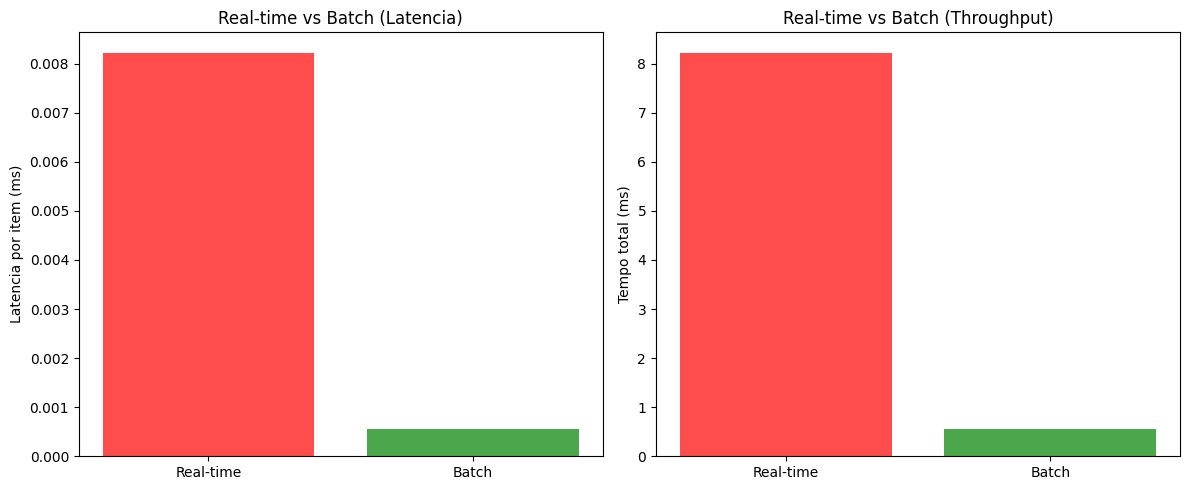

In [9]:
# Batch vs Real-time
class InferenceEngine:
    def __init__(self, modelo):
        self.modelo = modelo
        self.latencias_realtime = []
        self.latencias_batch = []

    def realtime(self, features):
        # Predicao uma por uma
        inicio = time()
        X = np.array(features).reshape(1, -1)
        predicao = self.modelo.predizer_proba(X)[0]
        tempo_ms = (time() - inicio) * 1000
        self.latencias_realtime.append(tempo_ms)
        return predicao[1]

    def batch(self, features_list, tamanho_batch=32):
        # Processar em lotes
        inicio = time()
        X = np.array(features_list)
        predicoes = self.modelo.predizer_proba(X)
        tempo_ms = (time() - inicio) * 1000
        self.latencias_batch.append(tempo_ms / len(features_list))  # Tempo por item
        return predicoes[:, 1]

    def comparar(self):
        return {
            'realtime_media_ms': float(np.mean(self.latencias_realtime)) if self.latencias_realtime else 0,
            'realtime_total_ms': float(np.sum(self.latencias_realtime)) if self.latencias_realtime else 0,
            'batch_media_ms': float(np.mean(self.latencias_batch)) if self.latencias_batch else 0,
            'speedup': float(np.mean(self.latencias_realtime) / np.mean(self.latencias_batch)) if self.latencias_batch and self.latencias_realtime else 0
        }

engine = InferenceEngine(modelo)

# Real-time: 1000 predicoes uma por uma
print("Real-time...")
for i in range(1000):
    features = np.random.randn(10).tolist()
    engine.realtime(features)

# Batch: mesmas 1000 predicoes em lotes de 32
print("Batch...")
X_batch = [np.random.randn(10).tolist() for _ in range(1000)]
for i in range(0, 1000, 32):
    engine.batch(X_batch[i:i+32])

print("\nComparacao Real-time vs Batch:")
comp = engine.comparar()
print(json.dumps(comp, indent=2))
print(f"Batch e {comp['speedup']:.1f}x mais rapido!")

# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(['Real-time', 'Batch'],
        [comp['realtime_media_ms'], comp['batch_media_ms']],
        color=['red', 'green'], alpha=0.7)
ax1.set_ylabel('Latencia por item (ms)')
ax1.set_title('Real-time vs Batch (Latencia)')

ax2.bar(['Real-time', 'Batch'],
        [comp['realtime_total_ms'], comp['batch_media_ms'] * 1000],
        color=['red', 'green'], alpha=0.7)
ax2.set_ylabel('Tempo total (ms)')
ax2.set_title('Real-time vs Batch (Throughput)')

plt.tight_layout()
plt.show()

## 11. Erros Comuns em Deploy

**O que observar:**
**O que concluir:**
### Erro 1: Modelo sobreajustado em producao

Seu modelo tinha 95% accuracy em teste. Em producao, cai para 60%. Causa: data drift. Dados reais sao diferentes.**Solucao**: Monitorar distribuicao de inputs. Retrainar periodicamente com dados reais.

### Erro 2: Features nao normalizadas

Seu modelo em producao recebe valores em range [0, 1000] mas treino foi com [0, 1]. Predicoes ficam ruins.**Solucao**: Usar Pipeline que salva normalizador junto com modelo. Validar ranges na entrada.

### Erro 3: Latencia inesperada

Modelo prediz em 10ms no notebook. Em producao, demora 2 segundos. Causa: I/O, rede, carga alta.**Solucao**: Fazer load testing. Usar batch inference. Adicionar cache. Escalar horizontalmente.

### Erro 4: Modelo nao e determinístico

Mesma entrada produz predicoes diferentes. Causa: inicializacao aleatoria nao foi setada.**Solucao**: Sempre setar np.random.seed() nos testes. Serializar com seed.

### Erro 5: Inconsistencia entre treino e producao

Treino: features em formato X. Producao: features em formato Y. Modelo falha.**Solucao**: Documentar exatamente como dados devem vir. Validar entrada rigorosamente. Testar integracao.

## 12. Exercicios Praticos

**O que observar:**
**O que concluir:**
### Exercicio 1: Serializar e desserializar

Crie dois modelos com arquiteturas diferentes e compare os arquivos serializados.

In [10]:
# TAREFA DO ALUNO: Completar e analisar os resultados
modelo_pequeno = ModeloSimulado(n_features=10, n_hidden=3)
modelo_grande = ModeloSimulado(n_features=10, n_hidden=20)

serializar_modelo(modelo_pequeno, os.path.join(tempfile.gettempdir(), 'modelo_pequeno.json'))
serializar_modelo(modelo_grande, os.path.join(tempfile.gettempdir(), 'modelo_grande.json'))

import os
tamanho_pequeno = os.path.getsize(os.path.join(tempfile.gettempdir(), 'modelo_pequeno.json'))
tamanho_grande = os.path.getsize(os.path.join(tempfile.gettempdir(), 'modelo_grande.json'))

print(f"Tamanho modelo pequeno: {tamanho_pequeno} bytes")
print(f"Tamanho modelo grande: {tamanho_grande} bytes")
print(f"Razao: {tamanho_grande / tamanho_pequeno:.2f}x")

Modelo serializado em: /var/folders/pg/j2d1lxdx6yq8d2lg7n2l5npw0000gn/T/modelo_pequeno.json
Modelo serializado em: /var/folders/pg/j2d1lxdx6yq8d2lg7n2l5npw0000gn/T/modelo_grande.json
Tamanho modelo pequeno: 1295 bytes
Tamanho modelo grande: 7002 bytes
Razao: 5.41x


### Exercicio 2: Validar entrada com limites personalizados

**O que observar:**
**O que concluir:**

In [11]:
# TAREFA DO ALUNO: Completar e analisar os resultados
validador_estrito = ValidadorEntrada(n_features=10, valor_min=-1, valor_max=1)
validador_frouxo = ValidadorEntrada(n_features=10, valor_min=-1000, valor_max=1000)

features_teste = [0.5, -0.5, 0.1, 0.2, 0.3, 0.4, 0.1, 0.0, -0.2, 0.1]

valido_estrito, erros_estrito = validador_estrito.validar(features_teste)
valido_frouxo, erros_frouxo = validador_frouxo.validar(features_teste)

print(f"Validador estrito: {valido_estrito}")
print(f"Validador frouxo: {valido_frouxo}")



Validador estrito: True
Validador frouxo: True


### Exercicio 3: Monitorar multiplos endpoints

**O que observar:**
**O que concluir:**

In [12]:
# TAREFA DO ALUNO: Completar e analisar os resultados
monitor_predict = MonitorLatencia('/predict')
monitor_health = MonitorLatencia('/health')

# Simular latencias diferentes
for i in range(100):
    tempo_predict = np.random.gamma(shape=2, scale=1)  # Distribuicao mais realista
    monitor_predict.registrar(tempo_predict)

    tempo_health = np.random.gamma(shape=2, scale=0.1)  # Health check e mais rapido
    monitor_health.registrar(tempo_health)

print("=== predict ===" )
print(json.dumps(monitor_predict.estatisticas(), indent=2))
print("=== health ===" )
print(json.dumps(monitor_health.estatisticas(), indent=2))



=== predict ===
{
  "endpoint": "/predict",
  "total_requisicoes": 100,
  "latencia_media_ms": 1.7638621010586966,
  "latencia_min_ms": 0.12417856119299044,
  "latencia_max_ms": 6.853543567428909,
  "latencia_p95_ms": 4.0229185341079425,
  "latencia_p99_ms": 5.880053701488158,
  "taxa_erro": 0.0
}
=== health ===
{
  "endpoint": "/health",
  "total_requisicoes": 100,
  "latencia_media_ms": 0.21066472275694667,
  "latencia_min_ms": 0.009663389984307484,
  "latencia_max_ms": 0.671829900883856,
  "latencia_p95_ms": 0.47290704301699077,
  "latencia_p99_ms": 0.6663864177518872,
  "taxa_erro": 0.0
}


## 13. Resumo

- Hierarquia de Conceitos

**O que observar:**
**O que concluir:**
Deploy ML segue uma hierarquia clara de dependencias:

```
[Treino em Notebook]
    |
    V
[1. Serializacao] -> Modelo congelado em disco
    |
    V
[2. Validacao] -> Garantir entrada correta
    |
    V
[3. API] -> Expor modelo via HTTP
    |
    V
[4. Monitoramento] -> Rastrear performance
    |
    V
[5. Deployment] -> Colocar em producao
    |
    V
[6. Retraining] -> Volta ao inicio
```

### Pontos-chave

1. **Serializacao** e o fundamento: sem poder salvar/carregar, nao ha deploy
2. **Validacao** protege o modelo: dados ruins causam predicoes ruins
3. **API** e a interface: usuarios nunca acessam o modelo diretamente
4. **Monitoramento** e o alarme: detecta quando algo vai errado
5. **Deployment** e a execucao: move modelo para producao
6. **Retraining** e o ciclo: melhora continua

**O que observar:**
Toda empresa com modelos em producao lida com esses passos, independente de tamanho.

**O que concluir:**
Deploy nao e um passo apos o treinamento. Deploy e parte integral do ciclo de ML.

### Conexao com modulos anteriores

- **Treinamento** : Cria o modelo
- **Validacao** (3_0): Mede qualidade do modelo
- **Deploy** (6_1): Leva modelo para producao
- **Monitoramento** (futuro): Garante qualidade em producao

## 14. Checklist de Deploy

**O que observar:**
**O que concluir:**
Antes de enviar um modelo para producao, verifique:- [ ] Modelo foi serializado e desserializado com sucesso
- [ ] Validacao de entrada e implementada
- [ ] API tem endpoints bem definidos (/predict, /health)
- [ ] Monitoramento de latencia foi configurado
- [ ] Health checks respondem em < 100ms
- [ ] Testes unitarios passam
- [ ] Documentacao descreve formato de entrada/saida
- [ ] Modelo possui versao clara
- [ ] Plano de retraining existe
- [ ] Criticas de performance sao documentadas
- [ ] Casos de erro sao tratados
- [ ] Logs sao estruturados e consulquiveis

## 15. Proximos Passos

**O que observar:**
**O que concluir:**
### Nivel 1: Consolidacao (Semana 1)

Implemente tudo que aprendeu neste notebook:

1. Treine um modelo real
2. Serialize e valide desserializacao
3. Crie uma API simulada com validacao
4. Configure monitoramento de latencia
5. Documente arquitetura

### Nivel 2: Docker (Semana 2)

Containerize seu modelo:

1. Crie Dockerfile
2. Build e teste localmente
3. Configure environment variables
4. Implemente health checks em Docker
5. Use docker-compose para multiplas instancias

### Nivel 3: CI/CD (Semana 3)

Automatize testes e deploy:

1. Configure pytest para modelo
2. Crie workflow de CI (GitHub Actions)
3. Automatize docker build
4. Implemente canary deployment
5. Configure alertas

### Nivel 4: Cloud (Semana 4+)

Coloque em producao real:

1. Escolha plataforma (Railway, AWS, GCP)
2. Configure variaveis de ambiente
3. Implemente logging centralizado
4. Configure monitoramento (Prometheus/Grafana)
5. Monitore data drift

### Recursos Recomendados

- MLOps.community para discussoes
- Documentacao FastAPI
- Documentacao Docker
- Kubernetes basics (se escalar muito)

### Perguntas Para Reflexao

1. Como detectaria data drift em producao?

2. Como trataria retraining automatico?

3. Como explicaria predicoes para usuarios?

4. Como rollback se novo modelo quebra?

5. Como garantir privacidade dos dados?

## Conclusao

Deploy e a arte de manter modelos ML rodando confiavel, rapido e seguro em producao. E muito mais que apenas "colocar online". Requer planejamento, monitoramento e melhoria continua.

Parabens por completar este modulo! Voce agora entende os desafios reais de ML em producao.